In [1]:
import os
from typing import Tuple, Union, List
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from efficientnet_pytorch import EfficientNet

In [2]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Custom Dataset
class LensDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.data = []
        
        for label, cls in enumerate(self.classes):
            cls_path = os.path.join(root_dir, cls)
            for file in os.listdir(cls_path):
                if file.endswith('.npy'):
                    self.data.append((os.path.join(cls_path, file), label))
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        file_path, label = self.data[idx]
        image = np.load(file_path)  # Load .npy file
        image = torch.tensor(image, dtype=torch.float32)  # Convert to tensor
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [4]:
# Transformations with Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Normalize((0.5,), (0.25,))
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5,), (0.25,))
])

In [5]:
# Load Dataset
train_dataset = LensDataset("dataset/train", transform=train_transform)
test_dataset = LensDataset("dataset/val", transform=test_transform)

In [6]:
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Split the original training dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
class MultiLocallySelfAttention(nn.Module):

    """
    Implements a MultiLocallySelfAttention layer, which is a specialized form of multi-head self-attention
    designed to attend over local patches of an image.

    Attributes:
        embed_dim (int): Embedding dimensionality of the input.
        num_heads (int): Number of attention heads.
        num_patches (int): Number of patches in the image.
        dropout (float): Dropout rate for regularization.
        device (torch.device): Device to run the computations on.
        attn_mask (torch.Tensor): Attention mask for self-attention operation.
        mha (nn.MultiheadAttention): Standard multi-head attention layer.
    """

    def __init__(self, embed_dim: int, num_heads: int, num_patches: int, device: torch.device, dropout: float = 0.1):

        """
        Initializes the MultiLocallySelfAttention layer.

        Args:
            embed_dim (int): Dimensionality of the input embeddings.
            num_heads (int): Number of attention heads.
            num_patches (int): Number of patches in the image.
            device (torch.device): Device to run the computations on.
            dropout (float): Dropout rate for regularization. Default is 0.1.

        """

        super().__init__()

        # Store layer parameters
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.num_patches = num_patches
        self.dropout = dropout
        self.device = device

        # Initialize attention mask (a lower triangular matrix with True values)
        self.attn_mask = torch.eye(self.num_patches, self.num_patches, dtype=torch.bool, requires_grad=False)
        self.attn_mask = self.attn_mask.to(device)

        # Initialize multi-head attention layer
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, dropout, batch_first=True)

    def forward(self, key: Tensor, query: Tensor, value: Tensor) -> Tensor:

        """
        Performs the forward pass through the MultiLocallySelfAttention layer.

        Args:
            key (Tensor): The key tensor for attention mechanism.
            query (Tensor): The query tensor for attention mechanism.
            value (Tensor): The value tensor for attention mechanism.

        Returns:
            Tensor: The output tensor after applying multi-head attention.

        """

        # Apply multi-head attention
        x, _ = self.mha(query, key, value, attn_mask=self.attn_mask)

        return x

In [8]:
class FeedForward(nn.Module):

  def __init__(self,
               in_features: int,
               out_features: int,
               activation_function: nn.Module,
               num_hidden_neurons: int,
               num_hidden_layers: int,
               task_type: str,
               dropout: float = 0.1,):
    """

    Initializes a FeedForward neural network.
    The FeedForward class is a neural network module in PyTorch that represents a multi-layer
    feedforward neural network. The class takes as input the number of input features, output
    features, activation function, number of hidden neurons, number of hidden layers, and
    dropout rate. It initializes a list of PyTorch modules that defines the layers of the neural
    network, with a linear layer, activation function, and dropout layer for the first layer,
    and a sequence of linear, activation, and dropout layers for the subsequent hidden layers.
    The final layer is a linear layer followed by an activation function choosen by the task_type
    argument (Identity function if task_type='regression', Sigmoid if task_type='binary_classification'
    or Softmax if task_type='multi_classification'). The forward method of the class takes an input
    tensor and applies each layer in the list of PyTorch modules in sequence to produce an output
    tensor, which represents the output of the feedforward neural network.

    Args:
      -in_features (int): number of input features.
      -out_features (int): number of output features.
      -activation_function (nn.Module): activation function to be used in hidden layers.
      -final_activation_function (nn.Module): activation function to be used in final layer (depends on the task).
      -num_hidden_neurons (int): number of neurons in each hidden layer.
      -num_hidden_layers (int): number of hidden layers in the network.
      -task_type (str): Task to be solved by the neural network. Must be one of: 'regression', 'binary_classification' or 'multi_classification'.
      -dropout (float, optional): dropout probability. Defaults to 0.1.

    Attributes:
      -feedforward (nn.ModuleList): List with each layer of the neural network.

    """

    super(FeedForward,self).__init__()
    self.feedforward = nn.ModuleList()

    # add input layer
    self.feedforward.append(nn.Linear(in_features,num_hidden_neurons))
    self.feedforward.append(activation_function)
    self.feedforward.append(nn.Dropout(dropout))

    # add hidden layers
    for _ in range(num_hidden_layers):
      self.feedforward.append(nn.Linear(num_hidden_neurons,num_hidden_neurons))
      self.feedforward.append(activation_function)
      self.feedforward.append(nn.Dropout(dropout))

    if task_type=='regression':

      self.final_activation_function = nn.Identity()

    elif task_type=='binary_classification':

      self.final_activation_function = nn.Sigmoid()

      if out_features != 1:
        raise ValueError("task_type='binary_classification' only supports 1 neuron on the end of the neural network (out_features = 1). If you want to use more than one neuron, use 'multi_classification' instead.")

    elif task_type=='multi_classification':

      self.final_activation_function = nn.Softmax(dim=1)

    else:
      raise ValueError("task_type must be either of 'regression','binary_classification' or 'multi_classification'.")

    # add output layer
    self.feedforward.append(nn.Linear(num_hidden_neurons,out_features))
    self.feedforward.append(self.final_activation_function)

  def forward(self,x: Tensor)->Tensor:

    """

    Computes the forward pass of the feedforward neural network.
    Args:
       x (Tensor): input tensor of shape [batch_size, in_features]
    Returns:
       Tensor: output tensor of shape [batch_size, out_features]

    """

    for layer in self.feedforward:
      x = layer(x)
    return x

In [9]:
class TransformerLSABlock(nn.Module):

    """
    Implements a TransformerLSABlock, a building block for transformer models designed
    to work on image patches. This block contains multi-locally self-attention,
    feedforward network, and layer normalization components.

    Attributes:
        mlsa (MultiLocallySelfAttention): MultiLocallySelfAttention layer.
        first_norm (nn.LayerNorm): First layer normalization.
        feedforward (FeedForward): FeedForward neural network layer.
        second_norm (nn.LayerNorm): Second layer normalization.
        dropout_layer (nn.Dropout): Dropout layer for regularization.
        device (torch.device): Device to run the computations on.
        temperature (nn.Parameter): Temperature parameter for attention mechanism.
    """

    def __init__(self,
                 embed_dim: int,
                 num_heads: int,
                 num_patches: int,
                 num_hidden_neurons: int,
                 activation_function: nn.Module,
                 device: torch.device,
                 dropout: float = 0.1):
        """
        Initializes the TransformerLSABlock layer.

        Args:
            embed_dim (int): The dimensionality of the input embeddings.
            num_heads (int): Number of attention heads.
            num_patches (int): Number of patches in the image.
            num_hidden_neurons (int): Number of neurons in the hidden layer of the feedforward network.
            activation_function (nn.Module): Activation function used in the feedforward network.
            device (torch.device): Device to run the computations on.
            dropout (float, optional): Dropout rate for regularization. Default is 0.1.
        """

        super().__init__()

        # initialize the multi-locally self-attention layer
        self.mlsa = MultiLocallySelfAttention(embed_dim, num_heads, num_patches, device, dropout)

        # initialize the first layer normalization
        self.first_norm = nn.LayerNorm(embed_dim)

        # initialize the feedforward network
        self.feedforward = FeedForward(embed_dim, embed_dim, activation_function, num_hidden_neurons, num_hidden_layers=1,
                                       task_type='regression', dropout=dropout)

        # initialize the second layer normalization
        self.second_norm = nn.LayerNorm(embed_dim)

        # initialize the dropout layer
        self.dropout_layer = nn.Dropout(dropout)

        # the device to store the tensors on
        self.device = device

        # initialize temperature parameter (a scalar used to divide the queries)
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, key: torch.Tensor, query: Union[torch.Tensor, None] = None, value: Union[torch.Tensor, None] = None) -> torch.Tensor:
        """
        Performs the forward pass through the TransformerLSABlock layer.

        Args:
            key (Tensor): The key tensor for the attention mechanism.
            query (Union[Tensor, None], optional): The query tensor for the attention mechanism.
                                                  If None, it defaults to the key tensor divided by temperature.
                                                  Default is None.
            value (Union[Tensor, None], optional): The value tensor for the attention mechanism.
                                                   If None, it defaults to the key tensor.
                                                   Default is None.

        Returns:
            Tensor: The output tensor after applying multi-locally self-attention,
                    layer normalization, feedforward network, and dropout.
        """
        # Prepare key, query, and value tensors
        key = key.to(self.device)
        if query is None:
            query = (key / self.temperature).to(self.device)
        if value is None:
            value = key.to(self.device)

        # apply multi-locally self-attention
        value = value + self.mlsa(key, query, value)

        # apply first layer normalization
        value = self.first_norm(value)

        # apply feedforward network
        value = value + self.feedforward(value)

        # apply second layer normalization
        value = self.second_norm(value)

        # apply dropout
        value = self.dropout_layer(value)

        return value

In [10]:
class RelativisticPhysicalInformedEncoder(nn.Module):
    """
    A PyTorch module to perform inverse gravitational lensing using the Singular Isothermal Sphere (SIS) model.

    Attributes:
        pixel_scale (float): The scale of each pixel in the image, often in arcseconds per pixel.
        profile_size (int): The size of the image profile.
        half_profile_size (int): Half of the profile size.
        num_patches (int): Number of patches.
        embed_dim (int): Dimension of the embedding.
        num_heads (int): Number of heads in the transformer.
        num_hidden_neurons (int): Number of hidden neurons.
        eps (float): Float number used to avoid division by zero.
        transformer_activation_function (nn.Module): Activation function used in the transformer.
        num_transformer_blocks (int): Number of transformer blocks.
        device (torch.device): Device to which tensors will be moved.
        transformer (nn.ModuleList): List of transformer blocks.
        num_neurons_flatten (int): Number of neurons in the Flatten layer.
        grid_x (Tensor): Grid of x coordinates.
        grid_y (Tensor): Grid of y coordinates.
        flat_grid_x (Tensor): Flattened grid of x coordinates.
        flat_grid_y (Tensor): Flattened grid of y coordinates.
    """
    def __init__( self,
                  image_size: int,
                  patch_size: int ,
                  embed_dim: int,
                  num_patches: int,
                  num_heads: int,
                  num_hidden_neurons: int,
                  transformer_activation_function: nn.Module,
                  num_transformer_blocks: int,
                  device: torch.device,
                  dropout: float = 0.1,
                  pixel_scale:float =0.101,
                  k_min: float = 0.8,
                  k_max: float = 1.2,
                  eps: float = 1e-8
                  ):


        """
        Initialize the module.

        Args:
            image_size (int): The size of the image.
            patch_size (int): The size of each patch.
            embed_dim (int): The embedding dimension.
            num_patches (int): The number of patches.
            num_heads (int): The number of heads in the transformer.
            num_hidden_neurons (int): The number of hidden neurons.
            transformer_activation_function (nn.Module): The activation function used in the transformer.
            num_transformer_blocks (int): The number of transformer blocks.
            device (torch.device): The device to which tensors will be moved.
            dropout (float, optional): The dropout rate. Defaults to 0.1.
            pixel_scale (float, optional): The scale of each pixel in the image, often in arcseconds per pixel. Defaults to 0.101.
            k_min (float, optional): Minimum value of the potential correction parameter.  Defaults to 0.8.
            k_max (float, optional): Maximum value of the potencial correction parameter.  Defaults to 1.2.
            eps (float): Float number used to avoid division by zero. Defaluts to 1e-8.
        """

        super(RelativisticPhysicalInformedEncoder, self).__init__()

        # Initialize variables
        self.pixel_scale = pixel_scale
        self.profile_size = image_size
        self.half_profile_size = self.profile_size // 2
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.num_hidden_neurons = num_hidden_neurons
        self.transformer_activation_function = transformer_activation_function
        self.num_transformer_blocks = num_transformer_blocks
        self.device = device
        self.k_min = k_min
        self.k_max = k_max
        self.eps = eps

        # Create an empty list for the transformer blocks
        self.transformer = nn.ModuleList()

        # Calculate the number of neurons for the Flatten layer
        self.num_neurons_flatten = (self.num_patches)*embed_dim

        # Create an empty list for the transformer blocks
        self.transformer = nn.ModuleList()

        # Create a for loop that iterates over the number of transformer blocks

        for _ in range(num_transformer_blocks):
          # Add a TransformerLSABlock to the transformer list
          self.transformer.append(

              TransformerLSABlock(embed_dim,
                                  num_heads,
                                  self.num_patches,
                                  num_hidden_neurons,
                                  transformer_activation_function,
                                  device,
                                  dropout)
          )

        # Create a compressor (FeedFoward) compress the size of num_neurons_flatten
        self.transformer.append(nn.Flatten())
        self.transformer.append(nn.Linear(self.num_neurons_flatten,self.profile_size*self.profile_size))
        self.transformer.append(nn.Sigmoid())

        # Create a grid for image coordinates
        x_coordinates = torch.linspace(-self.half_profile_size, self.half_profile_size-1, self.profile_size) * self.pixel_scale
        y_coordinates = torch.linspace(-self.half_profile_size, self.half_profile_size-1, self.profile_size) * self.pixel_scale
        self.grid_x, self.grid_y = torch.meshgrid(x_coordinates, y_coordinates)
        self.flat_grid_x = self.grid_x.flatten().to(self.device)
        self.flat_grid_y = self.grid_y.flatten().to(self.device)


    def forward(self, input_images: Tensor, patches: Tensor)->Tensor:

        """
        Forward pass through the module.

        Args:
            input_images (torch.Tensor): The input images.
            patches (torch.Tensor): The patches extracted from the images.

        Returns:
            output_images (torch.Tensor): The output images after inverse gravitational lensing.
        """

        # Get the batch size from the input images
        batch_size = input_images.shape[0]

        # Generate k using the sequential model
        for i, layer in enumerate(self.transformer):
            if i == 0:
                k_sigmoid = layer(patches)
            else:
                k_sigmoid = layer(k_sigmoid)

        # Reshape k_sigmoid to have shape [batch_size, profile_size, profile_size]
        k_sigmoid = k_sigmoid.view(-1, self.profile_size, self.profile_size)

        # Flatten k_sigmoid to match the shape of non_zero_x and non_zero_radius
        k_sigmoid_flat = k_sigmoid.view(-1, self.profile_size*self.profile_size)

        # Bias and Scalling
        k_sigmoid_flat = self.k_min + (self.k_max-self.k_min)*k_sigmoid_flat

         # Flatten the input images for easier indexing
        flat_input_images = input_images.view(batch_size, -1)

        # Create a mask for non-zero coordinates in the grid
        non_zero_mask = (self.flat_grid_x != 0) | (self.flat_grid_y != 0)

        # Select only the non-zero indices to match with non_zero_x and non_zero_radius
        k_sigmoid_non_zero = k_sigmoid_flat[:, non_zero_mask]

        # Get the shape of k_sigmoid_non_zero
        shape_k_sigmoid_non_zero = k_sigmoid_non_zero.shape

        # Reshape k to have a batch dimension compatible for broadcasting
        k = k_sigmoid_non_zero.view(shape_k_sigmoid_non_zero[0], 1, 1, shape_k_sigmoid_non_zero[1])

        # Apply the mask to get non-zero coordinates
        non_zero_x = self.flat_grid_x[non_zero_mask]
        non_zero_y = self.flat_grid_y[non_zero_mask]

        # Calculate the radius for non-zero coordinates
        non_zero_radius = torch.sqrt(non_zero_x ** 2 + non_zero_y ** 2)

        # Expand dimensions for broadcasting
        non_zero_radius = non_zero_radius[None, None, None, :]

        # Compute shifted coordinates based on the Gravitational Lens Equation to SIS model
        shifted_x = (non_zero_x[None, None, None, :] - k * non_zero_x[None, None, None, :] / non_zero_radius)
        shifted_y = (non_zero_y[None, None, None, :] - k * non_zero_y[None, None, None, :] / non_zero_radius)

        # Convert shifted coordinates to indices in the image grid
        shifted_x_idx = torch.round(shifted_x / self.pixel_scale + self.half_profile_size).long()
        shifted_y_idx = torch.round(shifted_y / self.pixel_scale + self.half_profile_size).long()

        # Initialize the output image tensor and flatten it
        output_images = torch.zeros(batch_size, self.profile_size, self.profile_size).to(self.device)
        flat_output_images = output_images.view(batch_size, -1)

        # Calculate 1D indices from shifted_x_idx and shifted_y_idx
        one_d_indices = shifted_x_idx * self.profile_size + shifted_y_idx

        # Flatten the input images for easier indexing
        flat_input_images = input_images.view(batch_size, -1)

        # Get the current values at the shifted positions in the flat output images
        output_values_at_shifted_positions = flat_output_images.gather(1, one_d_indices.view(batch_size, -1))

        # Get the corresponding values from the original positions in the flat input images
        input_values_at_original_positions = flat_input_images[:, non_zero_mask]

        # Update the output image based on the algorithm
        updated_values = torch.where(output_values_at_shifted_positions == 0,
                                    input_values_at_original_positions,
                                    (output_values_at_shifted_positions + input_values_at_original_positions) / 2)

        # Assign the updated values back to the flat output images
        flat_output_images.scatter_(1, one_d_indices.view(batch_size, -1), updated_values)

        # Reshape the flat output images back to their original shape
        output_images = flat_output_images.view(batch_size, self.profile_size, self.profile_size)


        # Normalize the output images
        max_values, _ = output_images.max(dim=1, keepdim=True)
        max_values, _ = max_values.max(dim=2, keepdim=True)
        output_images = output_images / (max_values + self.eps)

        return output_images

In [11]:
class PhysicsInformedFusionNet(nn.Module):
    def __init__(self,
                 num_classes: int,
                 image_size: int,         # e.g., 150
                 patch_size: int,         # e.g., 10  --> num_patches = (150/10)^2 = 225
                 embed_dim: int,          # embedding dimension for patches and encoder tokens
                 num_heads: int,
                 num_hidden_neurons: int,
                 transformer_activation_function: nn.Module,
                 num_transformer_blocks: int,
                 device: torch.device,
                 dropout: float = 0.1,
                 pixel_scale: float = 0.101,
                 k_min: float = 0.8,
                 k_max: float = 1.2,
                 eps: float = 1e-8):
        super(PhysicsInformedFusionNet, self).__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.device = device
        
        # ----- Physics-Informed Branch -----
        # Unfold patches from the 1-channel input image.
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2  # e.g., 225 patches
        patch_area = patch_size * patch_size
        # Since input is 1 channel, each patch has dimension 1 * patch_area.
        # Project flattened patches to embed_dim.
        self.patch_projector = nn.Linear(1 * patch_area, embed_dim)
        
        # Physics-informed encoder: expected to produce an output image.
        self.physics_module = RelativisticPhysicalInformedEncoder(
            image_size=image_size,
            patch_size=patch_size,
            embed_dim=embed_dim,
            num_patches=num_patches,
            num_heads=num_heads,
            num_hidden_neurons=num_hidden_neurons,
            transformer_activation_function=transformer_activation_function,
            num_transformer_blocks=num_transformer_blocks,
            device=device,
            dropout=dropout,
            pixel_scale=pixel_scale,
            k_min=k_min,
            k_max=k_max,
            eps=eps
        )
        
        # ----- EfficientNet Branch -----
        # Load a pretrained EfficientNet-B0.
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b0')
        # Modify the first conv layer to accept 2 channels (original + physics output)
        self._modify_efficientnet_input_channels(2)
        # Replace final FC to produce num_classes.
        in_features = self.efficientnet._fc.in_features
        self.efficientnet._fc = nn.Linear(in_features, num_classes)
    
    def _modify_efficientnet_input_channels(self, in_channels: int):
        # EfficientNet-B0 uses _conv_stem as the first convolution.
        first_conv = self.efficientnet._conv_stem
        new_conv = nn.Conv2d(
            in_channels,
            first_conv.out_channels,
            kernel_size=first_conv.kernel_size,
            stride=first_conv.stride,
            padding=first_conv.padding,
            bias=False
        )
        with torch.no_grad():
            # Initialize additional channel(s) by averaging the original weights.
            if in_channels > 1:
                new_conv.weight.copy_(first_conv.weight.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1))
            else:
                new_conv.weight.copy_(first_conv.weight)
        self.efficientnet._conv_stem = new_conv

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, 1, image_size, image_size] e.g. [B, 1, 150, 150]
        """
        B, C, H, W = x.shape
        
        # ----- Physics-Informed Path -----
        # Extract patches from the input image.
        patches = self.unfold(x)            # shape: [B, 1 * patch_area, num_patches]
        patches = patches.transpose(1, 2)     # shape: [B, num_patches, patch_area]
        patches = self.patch_projector(patches)  # shape: [B, num_patches, embed_dim]
        # Compute the physics-informed output.
        # Expected output might not have the desired spatial dimensions.
        physics_output = self.physics_module(x, patches)
        # Interpolate physics_output to ensure it is [B, 1, image_size, image_size].
        # The physics_module output might have a different spatial size; we force it here.
        physics_output = F.interpolate(physics_output.unsqueeze(1),
                                       size=(self.image_size, self.image_size),
                                       mode='bilinear',
                                       align_corners=False)
        # ----- Fusion -----
        # Concatenate original image and physics output along the channel dimension.
        # Both are [B, 1, image_size, image_size] -> fused_input becomes [B, 2, image_size, image_size].
        fused_input = torch.cat([x, physics_output], dim=1)
        
        # ----- Classification via EfficientNet -----
        logits = self.efficientnet(fused_input)
        return logits


In [12]:
model = PhysicsInformedFusionNet(
    num_classes=3,
    image_size=150,
    patch_size=10,
    embed_dim=128,
    num_heads=8,
    num_hidden_neurons=256,
    transformer_activation_function=nn.ReLU(),
    num_transformer_blocks=3,
    device=device
).to(device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loaded pretrained weights for efficientnet-b0


In [13]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # Reduce LR every 5 epochs

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, save_path='best_model.pth'):
    best_auc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_train_loss = running_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                probs = F.softmax(outputs, dim=1)
                all_probs.extend(probs.cpu().numpy())  # full class probabilities
                all_labels.extend(labels.cpu().numpy())

        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)

        # Compute per-class AUC and macro-average AUC
        auc_scores = []
        for i in range(all_probs.shape[1]):
            try:
                binary_labels = (all_labels == i).astype(int)
                auc = roc_auc_score(binary_labels, all_probs[:, i])
            except ValueError:
                auc = 0.0  # Not enough positive/negative samples for this class
            auc_scores.append(auc)

        macro_auc = np.mean(auc_scores)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Macro-AUC: {macro_auc:.4f}")

        # Save best model based on macro AUC
        if macro_auc > best_auc:
            best_auc = macro_auc
            torch.save(model.state_dict(), save_path)
            print(f"Saved new best model with Macro-AUC: {best_auc:.4f}")

In [15]:
# ROC-AUC Evaluation
def evaluate_model(model, test_loader, checkpoint_path='best_model.pth'):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    auc_scores = []
    for i in range(3):
        fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        auc_score = roc_auc_score((all_labels == i).astype(int), all_probs[:, i])
        auc_scores.append(auc_score)

        plt.plot(fpr, tpr, label=f"Class {i} (AUC: {auc_score:.2f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    print(f"Mean AUC Score: {np.mean(auc_scores):.4f}")

In [16]:
# Train and Evaluate
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50)

Epoch 1/50: 100%|██████████| 844/844 [01:30<00:00,  9.28it/s]


Epoch [1/50], Train Loss: 1.0844, Val Macro-AUC: 0.6616
Saved new best model with Macro-AUC: 0.6616


Epoch 2/50: 100%|██████████| 844/844 [01:30<00:00,  9.34it/s]


Epoch [2/50], Train Loss: 0.8805, Val Macro-AUC: 0.8373
Saved new best model with Macro-AUC: 0.8373


Epoch 3/50: 100%|██████████| 844/844 [01:30<00:00,  9.35it/s]


...

Epoch [48/50], Train Loss: 0.1273, Val Macro-AUC: 0.9910


Epoch 49/50: 100%|██████████| 844/844 [01:29<00:00,  9.39it/s]


Epoch [49/50], Train Loss: 0.1267, Val Macro-AUC: 0.9903


Epoch 50/50: 100%|██████████| 844/844 [01:29<00:00,  9.41it/s]


Epoch [50/50], Train Loss: 0.1221, Val Macro-AUC: 0.9909


Evaluating: 100%|██████████| 235/235 [00:10<00:00, 23.45it/s]


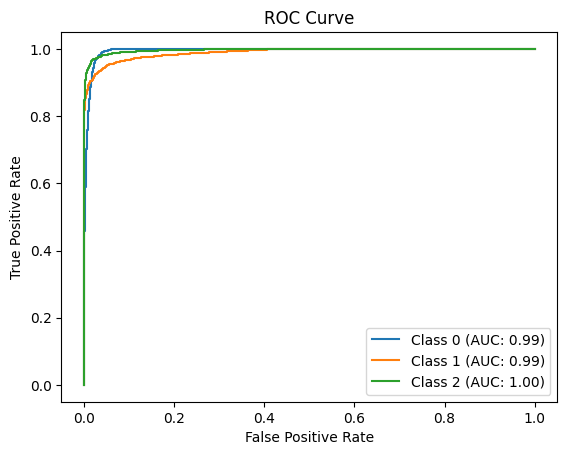

Mean AUC Score: 0.9933


In [17]:
evaluate_model(model, test_loader)